# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [4]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [6]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [14]:
print(usage.isna().sum())# Cantidad de valores nulos)
print(usage.isna().mean())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
-  en users existen valores faltantes: city con 469 valores que corresponde al 11.73% y churn_date con 3534 valores que corresponde a 88.35%
- en usage existen valores faltantes: date con 50 valores que corresponde al 0.13%,
duration con 22076 valores que corresponde al 55.19% y length con 17896 valores que corresponde al 44.74%
- Indica qué harías: ¿imputar, eliminar, ignorar?
los valores de city los imputaría ya que el porcentaje entra del 5% al 30%, churn_date lo ignoraría ya que son la gran mayoría de valores, date los dejo como nulo ya que corresponden a muy pocos valores con respecto al total, duration y length los imputaría ya que representan casi la mitad de los datos y son importantes para el analisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presenta datos con valor maximo muy alto sin embargo el promedio junto con el 50% son valores identicos, pero lo mas importante es que la desviacion estandar es muy alta ya que se encuntra muy alejada con respecto al promedio.
- La columna `age` tiene un problema con los datos ya que la desviacion estandar es de 123 que es algo que no tiene sentido, ya que el promedio de edad es de 33 y como podemos observar la edad minima es de -999 lo que es incoherente, lo que lo convierte en un claro sentinel.

In [16]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`existe una diferencia ya que cada usuario aparece en promedio unas 10 veces, ya que solo cuenta con 4000 valores distintos del 10000 al 13999 caso contrario en id es desde el 1 al 40000.
- Las columnas 'duration' y 'length' podriamos decir que la media es bastante más alta que la mediana, tendria una distribucion sesgada a la derecha, ya que la media es mayor que la mediana, generalmente indica que hay un grupo de valores altos, osea que existen llamadas muy largas que arrastran el promedio hacia arriba, aunque la mayoría de las llamadas son más cortas, en cambio en length aquí la diferencia es mucho más pequeña (52.12 vs 50, apenas un 4% de diferencia), podriamos decir que seria una distribución mucho más simétrica, sin un sesgo fuerte.

In [17]:
# explorar columnas categóricas de users
users["city"].unique()

array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [18]:
users["plan"].unique()

array(['Basico', 'Premium'], dtype=object)

- La columna `city`  se muestran que existen valores sentinel ya que hay valores con "?" para representar un dato en vez de dejarlo vacio, ademas aparecen nan que justamente es la forma estandar de representar un valor realmente faltante.
- La columna `plan` unicamente existen dos opciones que serian el basico y premium.

In [19]:
# explorar columna categórica de usage
usage['type'].unique()# completa el código

array(['call', 'text'], dtype=object)

- La columna `type` solo muestra dos alternativas call o text.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? en la columna city y age  
- ¿Qué acción tomarías?  detectar cuantos valores invalidos o sentiles existen y ver si se podrian imputar los valores, eliminarlos o no tomarlos en cuenta. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [20]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [21]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])# completa el código

In [22]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` solo existen 4 años (2022,2023,2024 y 2026) en donde los 40 valores del año 2026 son inconsistentes, ya que no hay datos registrados en ese año, unicamente hasta 2024 

In [23]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`,unicamente existe el año 2024, quedando pendiente 50 valores nulos verdaderos
Basaremos el análisis en estas fechas.

In [24]:
usage['date'].isna().sum()

50

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) aparecen 40 datos en el año 2026 
- ¿Qué harías con ellas? se tendrian que corregir el dato de la columna date, ya que seria raro ver datos en ese año si realmente hay registro hasta 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
users["age"].unique()


array([38., 53., 57., 69., 63., 61., 39., 70., 76., 47., 67., 60., 78.,
       77., 25., 51., 74., 64., 26., 68., 37., 42., 36., 22., 28., 32.,
       40., 44., 49., 43., 79., 59., 46., 56., 58., 50., 54., 33., 24.,
       29., 45., 66., 30., 35., 65., 18., 55., 19., 23., 41., 27., 34.,
       72., 75., 31., 71., 52., 20., 73., 21., 62., 48.])

In [27]:
users['age'].apply(type).value_counts()

<class 'float'>    4000
Name: age, dtype: int64

In [28]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", None)

# Verificar cambios
users["city"].unique()

array(['Medellín', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [29]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year==2026,"reg_date"]=np.nan

# Verificar cambios
users["reg_date"].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

In [30]:
users["reg_date"].isna().sum()

40

In [31]:
usage['duration'] = usage["duration"].replace("-999", None)
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.122250
std,1154.844867,17.690408
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [32]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [33]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

In [34]:
usage["type"].value_counts()

text    22092
call    17908
Name: type, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`.
En el grupo text (que se supone son solo mensajes), hay 16 filas que sí tienen un valor en duration (cuando "deberían" tenerlo nulo, porque un mensaje no tiene duración de llamada).
En el grupo call (que se supone son solo llamadas), hay 12 filas que sí tienen un valor en length (cuando "deberían" tenerlo nulo, porque una llamada no tiene longitud de mensaje).
Existen 28 filas que deberian tener nan.

In [35]:
usage[(usage['type'] == "text") & (usage['duration'].notna())]

,id,user_id,type,date,duration,length
1414,1415,10399,text,2024-01-07 09:33:51.260781519,120.0,65.0
1824,1825,12936,text,2024-01-09 06:05:28.868221705,120.0,40.0
1932,1933,10189,text,2024-01-09 17:49:13.603840096,120.0,69.0
2972,2973,10085,text,2024-01-14 10:46:02.169054226,120.0,68.0
11456,11457,13325,text,2024-02-21 20:09:09.733743343,120.0,23.0
16702,16703,10484,text,2024-03-16 13:52:57.169429235,120.0,48.0
22814,22815,12711,text,2024-04-13 05:39:44.429610740,120.0,70.0
23052,23053,13850,text,2024-04-14 07:30:35.235880896,120.0,24.0
23451,23452,13265,text,2024-04-16 02:50:32.175804394,120.0,53.0
26561,26562,13920,text,2024-04-30 04:35:48.173704342,120.0,89.0


In [36]:
usage[(usage['type'] == "call") & (usage['length'].notna())]

,id,user_id,type,date,duration,length
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,1490.0
5272,5273,11750,call,2024-01-24 20:33:12.649816245,3.78,1490.0
10614,10615,13855,call,2024-02-18 00:42:33.183829595,0.53,1490.0
12692,12693,12263,call,2024-02-27 10:23:08.374709367,1.80,1490.0
16910,16911,12099,call,2024-03-17 12:28:18.882472061,3.29,1490.0
20727,20728,10599,call,2024-04-03 19:00:30.510762768,0.40,1490.0
20778,20779,11401,call,2024-04-04 00:32:49.969249231,1.01,1490.0
25444,25445,10781,call,2024-04-25 03:17:14.935873396,3.57,1490.0
26057,26058,11018,call,2024-04-27 21:51:39.407485186,0.63,1490.0
26506,26507,12400,call,2024-04-29 22:37:24.836120902,1.12,1490.0


In [37]:
usage.loc[((usage['type'] == "text") & (usage['duration'].notna())),'duration']=None
usage[(usage['type'] == "text") & (usage['duration'].notna())]

,id,user_id,type,date,duration,length


In [38]:
usage.loc[((usage['type'] == "call") & (usage['length'].notna())),'length']=None
usage[(usage['type'] == "call") & (usage['length'].notna())]

,id,user_id,type,date,duration,length


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [39]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)#conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({"is_text":"sum","is_call":"sum","duration":"sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [40]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamadas"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [41]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id",how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [42]:
# Resumen estadístico de las columnas numéricas
user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamadas"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,22.836934
std,17.690408,2.358416,2.144238,16.590213
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000
50%,47.000000,5.000000,4.000000,19.740000
75%,63.000000,7.000000,6.000000,31.185000
max,79.000000,17.000000,15.000000,155.690000


In [43]:
# Distribución porcentual del tipo de plan
users["plan"].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

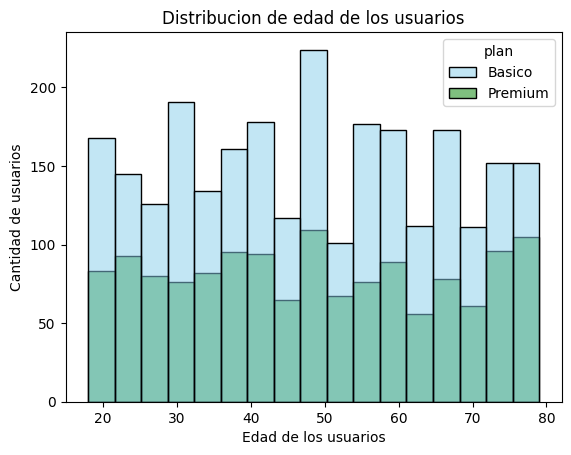

In [44]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age",hue='plan',palette=['skyblue','green'])
plt.xlabel("Edad de los usuarios")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion de edad de los usuarios")
plt.show()

💡Insights: Podemos observar que la mayoria de los usuarios tienen un edad que va de los 45 a 50 años.
- Distribución podria ser simetrica ya que no existe un sesgo muy notorio ya que los valores de mean y median son muy parecidas, puesto que la diferencia es de 1.12

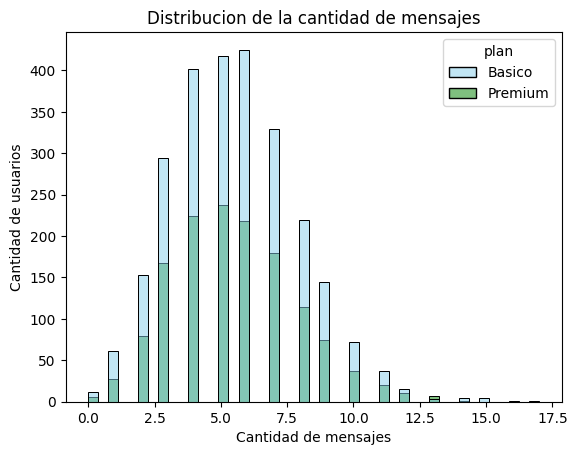

In [45]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes",hue='plan',palette=['skyblue','green'])
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion de la cantidad de mensajes")
plt.show()


💡Insights: 
- Normalmente en promedio la mayoria de los ususarios tienden a enviar de 5 a 6 mensajes, pero como se puede observar esxiste un poco de sesgo a la derecha ya que hay algunos usuarios que envian hasta 17 mensajes lo que hace que se estire el promedio

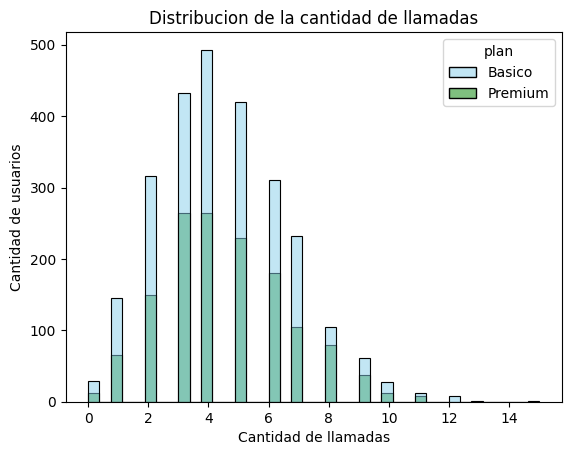

In [46]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas",hue='plan',palette=['skyblue','green'])
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion de la cantidad de llamadas")
plt.show()


💡Insights: 
- Normalmente en promedio la mayoria de los ususarios tienden a realizar de 4 a 5 llamadas, pero como se puede observar existe un poco de sesgo a la derecha ya que hay algunos usuarios que llaman hasta 15 veces lo que hace que estos valores altos estiren el promedio.

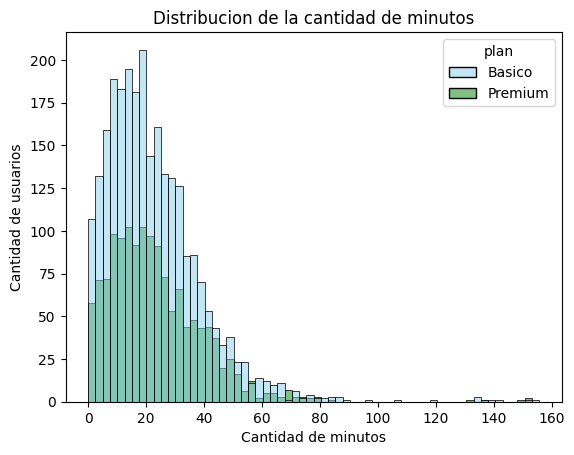

In [47]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamadas",hue='plan',palette=['skyblue','green'])
plt.xlabel("Cantidad de minutos")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribucion de la cantidad de minutos")
plt.show()

💡Insights: 
- Definitivamente existe un sesgo a la derecha ya que el promedio es mucho mayor a la mediana 22.84>19.74, ademas de este dato, los valores se estiran a la derecha ya que existen usuarios que llaman hasta 155.69 minutos

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

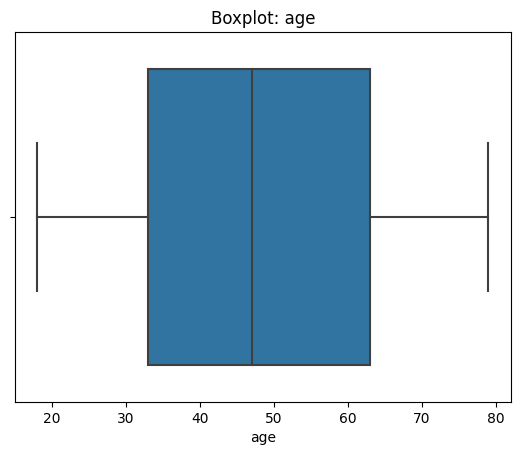

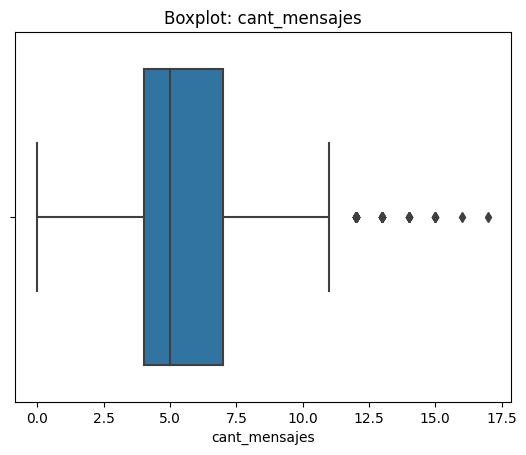

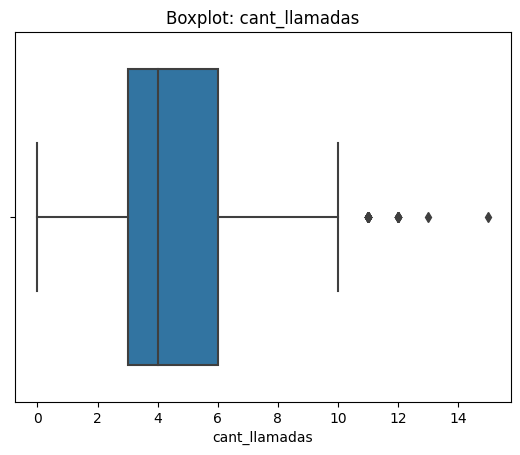

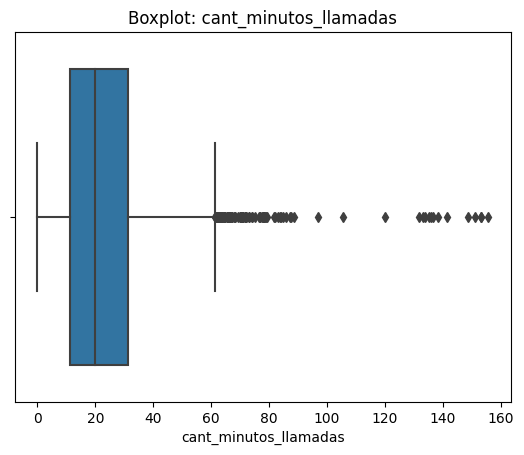

In [48]:
# Visualizando usando BoxPlot
columnas_numericas=["age", 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']
for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers 
- cant_minutos_llamada: presenta una enorme cantidad de outliers

In [49]:
# Calcular límites con el método IQR
columnas_limites = ["age", 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']
for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR = Q3-Q1
    print(f'Limite inferior de {col}:',Q1-1.5*IQR)
    print(f'Limite superior de {col}:',Q3+1.5*IQR)

Limite inferior de age: -12.0
Limite superior de age: 108.0
Limite inferior de cant_mensajes: -0.5
Limite superior de cant_mensajes: 11.5
Limite inferior de cant_llamadas: -1.5
Limite superior de cant_llamadas: 10.5
Limite inferior de cant_minutos_llamadas: -19.04
Limite superior de cant_minutos_llamadas: 61.31999999999999


In [50]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,22.836934
std,17.690408,2.358416,2.144238,16.590213
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000
50%,47.000000,5.000000,4.000000,19.740000
75%,63.000000,7.000000,6.000000,31.185000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Se detectaron valores atípicos en cant_mensajes por encima de 11.5, correspondientes a usuarios con un uso intensivo del servicio de mensajería. Estos valores no se consideran errores, sino un comportamiento real, por lo que se mantienen en el análisis.
- cant_llamadas: mantener o no outliers, porqué? Se detectaron valores atípicos en cant_llamadas por encima de 10.5, correspondientes a usuarios con un uso intensivo del servicio de llamadas. Estos valores no se consideran errores, sino un comportamiento real, por lo que se mantienen en el análisis.
- cant_minutos_llamada: mantener o no outliers, porqué? Se detectaron valores atípicos en cant_minutos_llamadas por encima de 61.32, estos valores no se consideran errores, con valores reales, pero tampoco sería conveniente mantenerlos en el analisis, ya que es una diferencia muy grande que podria afectar al analisis

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [51]:
# Crear columna grupo_uso
user_profile["grupo_uso"]= np.where(
    (user_profile["cant_llamadas"] <5) & (user_profile["cant_mensajes"] <5), "Bajo uso",
    np.where((user_profile["cant_llamadas"] <10) & (user_profile["cant_mensajes"] <10), "Uso medio",
    "Alto uso"))

In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [53]:
# Crear columna grupo_edad
user_profile["grupo_edad"]= np.where(
    (user_profile["age"] <30), "Joven",
    np.where((user_profile["age"] <60),"Adulto",
    "Adulto Mayor"))

In [54]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,Medellín,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [55]:
user_profile["grupo_edad"].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [56]:
user_profile["grupo_uso"].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

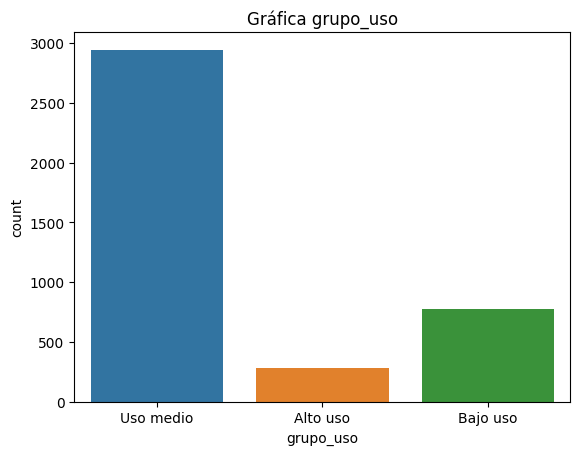

In [57]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")
plt.title('Gráfica grupo_uso')
plt.show()

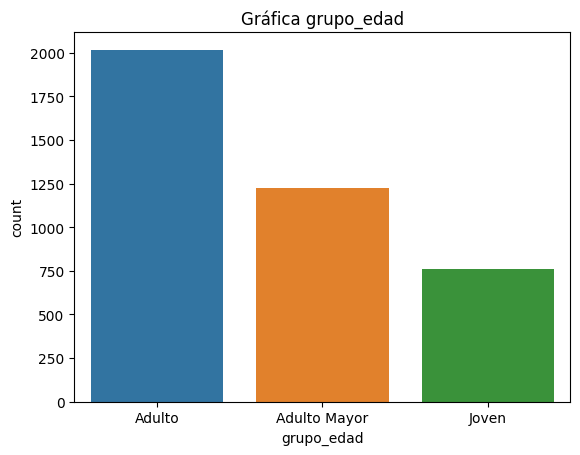

In [58]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")
plt.title('Gráfica grupo_edad')
plt.show()

In [67]:

condicion_1 = user_profile['grupo_edad'] == 'Adulto'
condicion_2 = user_profile['grupo_uso'] == 'Alto uso'

total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)

condicion_1 = user_profile['grupo_edad'] == 'Adulto'
condicion_2 = user_profile['grupo_uso'] == 'Uso medio'

total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)

condicion_1 = user_profile['grupo_edad'] == 'Adulto'
condicion_2 = user_profile['grupo_uso'] == 'Bajo uso'

total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)

154
1500
364


In [69]:


condicion_1 = user_profile['grupo_edad'] == 'Adulto Mayor'
condicion_2 = user_profile['grupo_uso'] == 'Alto uso'

total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)


condicion_1 = user_profile['grupo_edad'] == 'Adulto Mayor'
condicion_2 = user_profile['grupo_uso'] == 'Uso medio'

total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)

condicion_1 = user_profile['grupo_edad'] == 'Adulto Mayor'
condicion_2 = user_profile['grupo_uso'] == 'Bajo uso'

total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)




74
891
257


In [70]:

condicion_1 = user_profile['grupo_edad'] == 'Joven'
condicion_2 = user_profile['grupo_uso'] == 'Alto uso'


total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)


condicion_1 = user_profile['grupo_edad'] == 'Joven'
condicion_2 = user_profile['grupo_uso'] == 'Uso medio'

total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)

condicion_1 = user_profile['grupo_edad'] == 'Joven'
condicion_2 = user_profile['grupo_uso'] == 'Bajo uso'

total = user_profile[condicion_1 & condicion_2].shape[0]
print(total)


51
552
157


In [71]:

condicion_1 = user_profile['grupo_edad'] == 'Adulto'
condicion_2 = user_profile['grupo_uso'] == 'Alto uso'
condicion_3 = user_profile['plan'] == 'Premium'

total = user_profile[condicion_1 & condicion_2 & condicion_3].shape[0]
print(total)


46


In [72]:
condicion_1 = user_profile['grupo_edad'] == 'Adulto'
condicion_2 = user_profile['grupo_uso'] == 'Alto uso'
condicion_3 = user_profile['plan'] == 'Basico'

total = user_profile[condicion_1 & condicion_2 & condicion_3].shape[0]
print(total)

108



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

  
 En users existían valores faltantes: city con 469 valores que correspondían al 11.73% y churn_date con 3534 valores que correspondían a 88.35%, al igual que 
en usage existian valores faltantes: date con 50 valores que correspondían al 0.13%, duration con 22076 valores que correspondían al 55.19% y length con 17896 valores que correspondían al 44.74%

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

  Los segmentos de clinete que se identificaron fueron Adulto, Adulto Mayor y Joven, que de acuerdo a su nivel de uso, existen en primer lugar con 1500 adultos con un nivel de uso medio, en segundo lugar 891 adultos mayores con un nivel de uso medio y en tercer lugar 552 jovenes con un nivel de uso medio


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los adultos ya que representa el 50.45% de sus clientes

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

 De los usuarios de alto uso, más de la mitad (55.19%) son adultos, lo que sugiere que el consumo extremo está más asociado a ese grupo de edad que a otros y dentro de ese grupo existen 46 usuarios con plan premium y 108 usuarios con plan basico
 
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Para ese tipo de usuarios con alto uso de mensajes y llamadas es recomendable ofrecerles un mejor servicio, podria ser un plan ilimitado de mensajes y llamadas, sería crear un plan llamado VIP, y con ello tendrian mas libertad, ya sean adultos, adultos mayores y jovenes, de acuerdo a sus necesidades.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Habían outliers
- Habían datos inconsistentes en las edades, como por ejemplo que eran negativas.
- En el grupo text (que se supone son solo mensajes), habían 16 filas que sí tienian un valor en duration (cuando "deberían" tenerlo nulo, porque un mensaje no tiene duración de llamada).
En el grupo call (que se supone son solo llamadas), habían 12 filas que sí tienían un valor en length (cuando "deberían" tenerlo nulo, porque una llamada no tiene longitud de mensaje).
Existen 28 filas que deberian tener nan.


🔍 **Segmentos por Edad**
- En cuanto a las edades hay de tres tipo: los jovenes que van de 0 a 29 años, los adultos que van de los 30 a 59 años y los adultos mayores que van de los 60 años en adelante.
- Realizando el analisis pudimos observar que la mayoria de los usuarios son adultos dando un total de 2018 usuarios.


📊 **Segmentos por Nivel de Uso**
- Al realizar la segmentacion de los niveles de uso de la llamadas y mensajes realizados por cada usuario, pudimos observar que 2943 usuarios tienen un coportamiento de uso medio, esto representa el 73.57% del total.
- Ademas de esto se decto que tambien que son 279 usuarios que hacen en promedio mas de 10 mesnsajes y 10 llamadas, esto quiere decir que tienen un uso alto con respecto a los demas usuarios.

➡️ Esto sugiere que se podria tomar en cuenta para ofrecer otro tipo de plan y ofrecerles un mejor servicio a ese tipo de usuarios en específico, con alto uso de mensajes y llamadas.


💡 **Recomendaciones**
- Ofrecer un nuevo plan en donde los mensajes y llamadas sean ilimitados a los usuarios con un alto uso en especifico.
- 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`